In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [17]:
dro_path = "/net/scratch2/rachelgordon/test_dro_144frames.mat"

with h5py.File(dro_path, "r") as f:
    print(list(f.keys()))

    simImg = f['simImg'][:]

print(simImg.shape)

['#refs#', 'S0', 'mask', 'n_frames', 'parMap', 'simImg', 'smap']
(144, 320, 320)


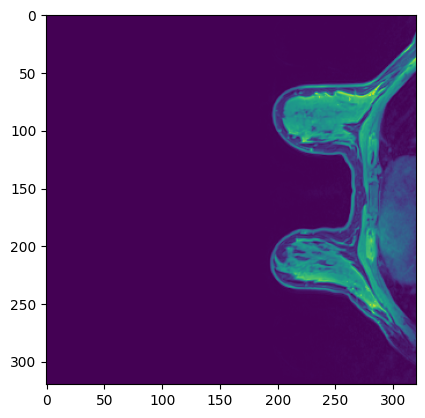

In [18]:
plt.imshow(simImg[0])

In [6]:
grasp_espirit = np.load('/net/scratch2/rachelgordon/dro/espirit_grasp_recons/grasp_sample_005_sub5_2spf.npy')
print(grasp_espirit.shape)

(320, 320, 22)


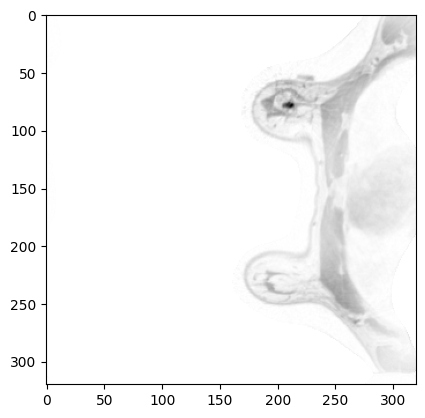

In [7]:
plt.imshow(np.abs(grasp_espirit[..., 0]), cmap="gray_r")

In [8]:
kspace_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_dro.mat"

with h5py.File(kspace_path, "r") as f:
    print(list(f.keys()))

    simImg = f['simImg'][:]

print(simImg.shape)

['#refs#', 'S0', 'mask', 'parMap', 'simImg', 'smap', 'this_id']
(22, 320, 320)


(-0.5, 319.5, 319.5, -0.5)

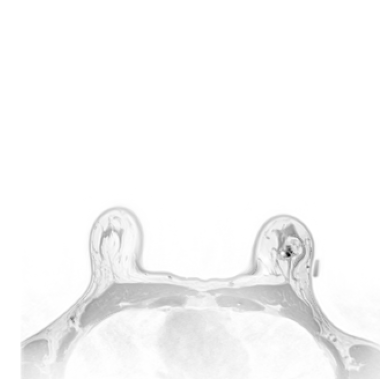

In [9]:
plt.imshow(np.rot90(simImg[0], k=3), cmap="gray_r")
plt.axis("off")

In [10]:
kspace_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_kspace_2spf.mat"

with h5py.File(kspace_path, "r") as f:
    print(list(f.keys()))

    kspace = f['kspace'][:]
    traj = f['traj'][:]
    spokes_per_frame = f['spokes_per_frame'][:]

print(kspace.shape)
print(traj.shape)
print(spokes_per_frame)

['kspace', 'n_lvl', 'spokes_per_frame', 'this_id', 'traj']
(16, 44, 640)
(44, 640)
[[2.]]


In [11]:
recon_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_recon_2spf.mat"

with h5py.File(recon_path, "r") as f:
    print(list(f.keys()))

    reco = f['reco'][:]
    grasp_bart = f['grasp_bart'][:]
    spokes_per_frame = f['spokes_per_frame'][:]

print(reco.shape)
print(grasp_bart.shape)
print(spokes_per_frame)

['grasp_bart', 'reco', 'spokes_per_frame', 'this_id']
(22, 1, 1, 1, 1, 1, 1, 1, 1, 320, 320)
(22, 320, 320)
[[2.]]


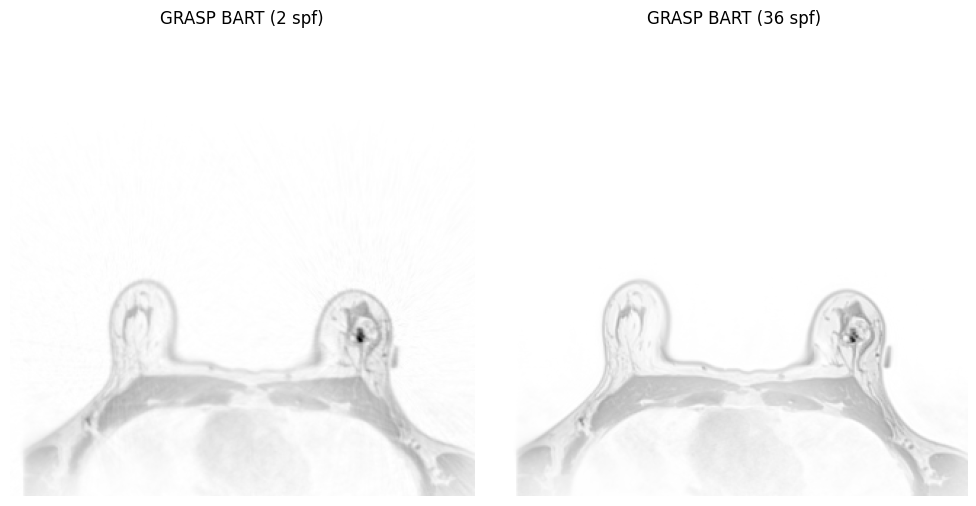

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

# --- First image (existing grasp_bart) ---
img1 = np.rot90(grasp_bart[0], k=3)

# --- Load second reconstruction ---
recon_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_recon_36spf.mat"

with h5py.File(recon_path, "r") as f:
    grasp_bart36 = f["grasp_bart"][:]

img2 = np.rot90(grasp_bart36[0], k=3)

# --- Optional: match intensity scaling ---
vmin = min(img1.min(), img2.min())
vmax = max(img1.max(), img2.max())

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1, cmap="gray_r", vmin=vmin, vmax=vmax)
axes[0].set_title("GRASP BART (2 spf)")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray_r", vmin=vmin, vmax=vmax)
axes[1].set_title("GRASP BART (36 spf)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


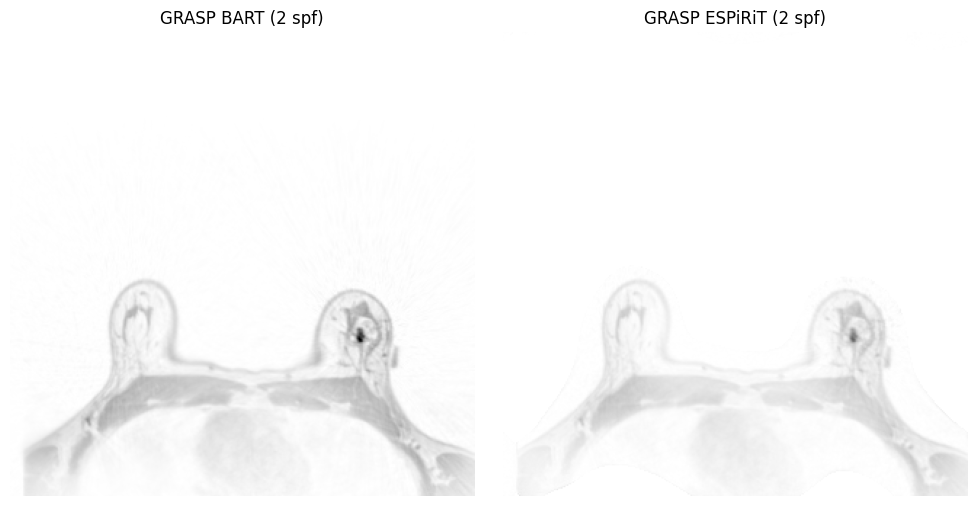

In [14]:
# --- First image (existing grasp_bart) ---
img1 = np.rot90(grasp_bart[0], k=3)

# --- Load second reconstruction ---
recon_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_recon_36spf.mat"

with h5py.File(recon_path, "r") as f:
    grasp_bart36 = f["grasp_bart"][:]

img2 = np.rot90(np.abs(grasp_espirit[..., 0]), k=3)

# --- Optional: match intensity scaling ---
vmin = min(img1.min(), img2.min())
vmax = max(img1.max(), img2.max())

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1, cmap="gray_r", vmin=vmin, vmax=vmax)
axes[0].set_title("GRASP BART (2 spf)")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray_r", vmin=vmin, vmax=vmax)
axes[1].set_title("GRASP ESPiRiT (2 spf)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

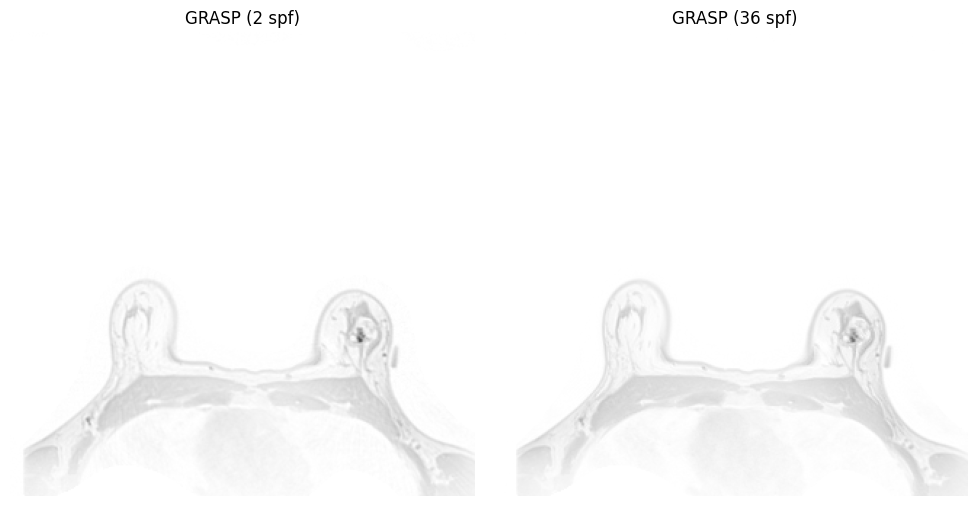

In [ ]:
old_dro_path = '/net/scratch2/rachelgordon/dro_dataset_frontpad/dro_144frames/sample_005_sub5/grasp_spf2_frames144_correct_traj_n0.05_espirit.npy'
old_dro_2spf = np.load(old_dro_path)

old_dro_path_36 = '/net/scratch2/rachelgordon/dro_dataset_frontpad/dro_8frames/sample_005_sub5/grasp_spf36_frames8_correct_traj_n0.05_espirit.npy'
old_dro_36spf = np.load(old_dro_path_36)


# --- Optional: match intensity scaling ---
vmin = min(img1.min(), img2.min())
vmax = max(img1.max(), img2.max())

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.abs(np.flip(old_dro_2spf[0], axis=1)), cmap="gray_r", vmin=vmin, vmax=vmax)
axes[0].set_title("GRASP (2 spf)")
axes[0].axis("off")

axes[1].imshow(np.abs(np.flip(old_dro_36spf[0], axis=1)), cmap="gray_r", vmin=vmin, vmax=vmax)
axes[1].set_title("GRASP (36 spf)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


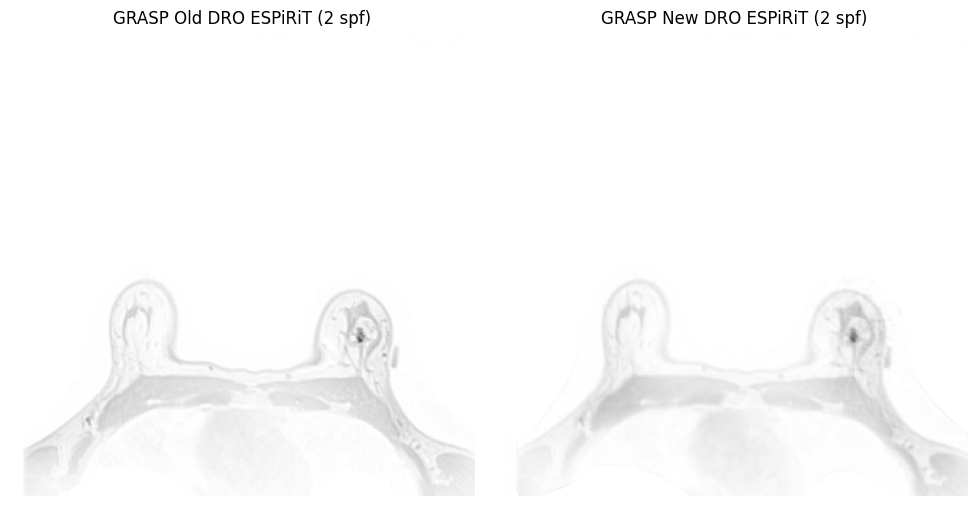

In [16]:
old_dro_path = '/net/scratch2/rachelgordon/dro_dataset_frontpad/dro_144frames/sample_005_sub5/grasp_spf2_frames144_correct_traj_n0.05_espirit.npy'
old_dro_2spf = np.load(old_dro_path)


# --- Optional: match intensity scaling ---
vmin = min(img1.min(), img2.min())
vmax = max(img1.max(), img2.max())

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.abs(np.flip(old_dro_2spf[0], axis=1)), cmap="gray_r", vmin=vmin, vmax=vmax)
axes[0].set_title("GRASP Old DRO ESPiRiT (2 spf)")
axes[0].axis("off")

axes[1].imshow(np.rot90(np.abs(grasp_espirit[..., 0]), k=3), cmap="gray_r", vmin=vmin, vmax=vmax)
axes[1].set_title("GRASP New DRO ESPiRiT (2 spf)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [36]:
dro_path = "/net/scratch2/rachelgordon/dro/sample_005_sub5_dro.mat"

with h5py.File(dro_path, "r") as f:
    print(list(f.keys()))

    simImg = f['simImg'][:]
    smap = f['smap'][:]

print(simImg.shape)
print(smap.shape)

['#refs#', 'S0', 'mask', 'parMap', 'simImg', 'smap', 'this_id']
(22, 320, 320)
(16, 320, 320)
